In [1]:
from importlib import reload
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import torch
import einops

In [2]:
sys.path.insert(0, f"{os.environ['HOME']}/dinov2")

In [3]:
import autopath.gigaq.dinov2.augmentations
reload(autopath.gigaq.dinov2.augmentations)
import autopath.gigaq.dinov2.dataset
reload(autopath.gigaq.dinov2.dataset)

 cuInit Failed, error CUDA_ERROR_NO_DEVICE
 cuFile initialization failed


<module 'autopath.gigaq.dinov2.dataset' from '/home/t-9dkarp/autopath/autopath/gigaq/dinov2/dataset.py'>

# DATASET

In [4]:
dataset = autopath.gigaq.dinov2.dataset.make_dataset(verbose=False)

In [6]:
sample, _ = next(iter(dataset))

In [7]:
sample.keys()

dict_keys(['global_crops', 'global_crops_teacher', 'local_crops', 'offsets'])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


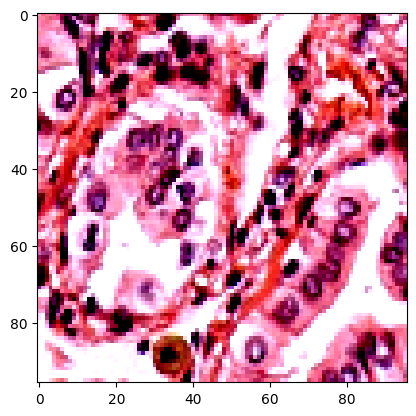

In [8]:
%matplotlib inline
image = sample['local_crops'][0]
plt.imshow(einops.rearrange(image, 'c h w -> h w c'))

# DATALOADER

In [9]:
import autopath.gigaq.dinov2.dataloader
reload(autopath.gigaq.dinov2.dataloader)

<module 'autopath.gigaq.dinov2.dataloader' from '/home/t-9dkarp/autopath/autopath/gigaq/dinov2/dataloader.py'>

In [10]:
%%time
dataloader = autopath.gigaq.dinov2.dataloader.make_dataloader(dataset)

CPU times: user 1.18 s, sys: 694 ms, total: 1.88 s
Wall time: 6.84 s


In [11]:
def unnorm(t):
    return ((t-t.min())/(t.max()-t.min())*255).byte()

In [12]:
dl0 = next(iter(dataloader))

In [13]:
dl0.keys()

dict_keys(['collated_global_crops', 'collated_local_crops', 'collated_masks', 'mask_indices_list', 'masks_weight', 'upperbound', 'n_masked_patches'])

In [14]:
cgc0 = dl0['collated_global_crops']
display(len(cgc0))
display(cgc0[0].shape)
display(cgc0[0].dtype)

8

torch.Size([3, 224, 224])

torch.float16

In [15]:
ucgc0 = unnorm(cgc0)
display(ucgc0.shape)
display(ucgc0.dtype)

torch.Size([8, 3, 224, 224])

torch.uint8

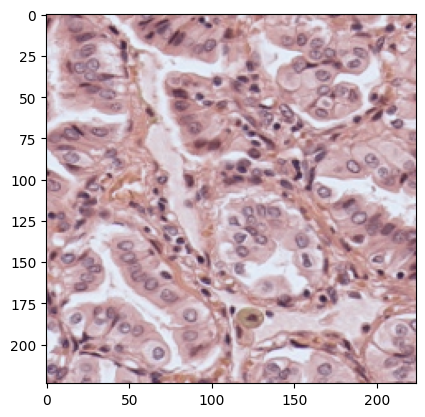

In [16]:
%matplotlib inline
plt.imshow(einops.rearrange(ucgc0[0], 'c h w -> h w c').numpy())